In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [45]:
df = pd.read_csv("data.csv")

print("Initial Data Overview")
print(df.info())

Initial Data Overview
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            7 non-null      object 
 1   Gender             5 non-null      object 
 2   Married            6 non-null      object 
 3   Dependents         6 non-null      object 
 4   Education          7 non-null      object 
 5   Self_Employed      6 non-null      object 
 6   ApplicantIncome    7 non-null      int64  
 7   CoapplicantIncome  7 non-null      int64  
 8   LoanAmount         6 non-null      float64
 9   Loan_Amount_Term   6 non-null      float64
 10  Credit_History     6 non-null      float64
 11  Property_Area      7 non-null      object 
 12  Loan_Status        7 non-null      object 
dtypes: float64(3), int64(2), object(8)
memory usage: 860.0+ bytes
None


In [47]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Loan_ID              0
Gender               2
Married              1
Dependents           1
Education            0
Self_Employed        1
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           1
Loan_Amount_Term     1
Credit_History       1
Property_Area        0
Loan_Status          0
dtype: int64


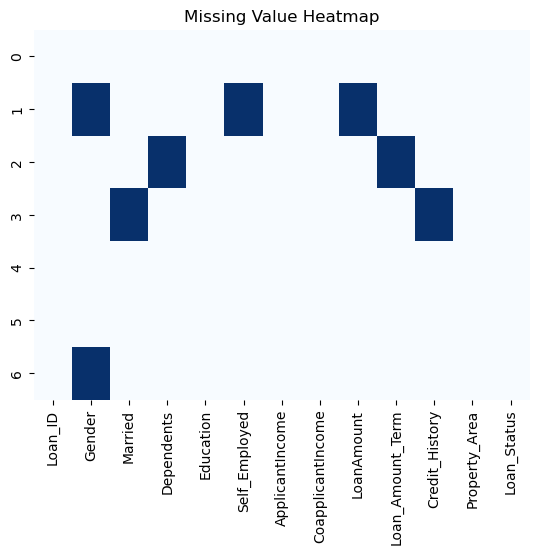

In [48]:
sns.heatmap(df.isnull(), cbar=False, cmap="Blues")
plt.title("Missing Value Heatmap")
plt.show()

In [49]:
for col in ["Gender", "Married", "Dependents", "Self_Employed"]:
    df[col] = df[col].fillna(df[col].mode()[0])

df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0])
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

initial_rows = len(df)
df.drop_duplicates(inplace=True)
print("\nDuplicates Removed:", initial_rows - len(df))


Duplicates Removed: 1


In [50]:
df["Dependents"] = df["Dependents"].replace("3+", 3).astype(int)

for col in ["Gender", "Married", "Education", "Self_Employed", "Property_Area"]:
    df[col] = df[col].str.strip().str.capitalize()

minmax = MinMaxScaler()
df[["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]] = minmax.fit_transform(
    df[["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]]
)

standard = StandardScaler()
df[["Credit_History"]] = standard.fit_transform(df[["Credit_History"]])

print("\nCleaned Data")
print(df.info())
print(df.head())


Cleaned Data
<class 'pandas.core.frame.DataFrame'>
Index: 6 entries, 0 to 6
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            6 non-null      object 
 1   Gender             6 non-null      object 
 2   Married            6 non-null      object 
 3   Dependents         6 non-null      int32  
 4   Education          6 non-null      object 
 5   Self_Employed      6 non-null      object 
 6   ApplicantIncome    6 non-null      float64
 7   CoapplicantIncome  6 non-null      float64
 8   LoanAmount         6 non-null      float64
 9   Loan_Amount_Term   6 non-null      float64
 10  Credit_History     6 non-null      float64
 11  Property_Area      6 non-null      object 
 12  Loan_Status        6 non-null      object 
dtypes: float64(5), int32(1), object(7)
memory usage: 648.0+ bytes
None
  Loan_ID  Gender Married  Dependents     Education Self_Employed  \
0   LP001    Male     Yes    